In [1]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [194]:
#AUTHOR : INVENTADO, CHARLES FREDRIC G.
#SECTION : 3CSE
#ACTIVITY : [F] Formative Lab Exercise #4: Training Your Multilayer Perceptron

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim

# Step 1: Download and Load the Dataset

- This step downloads the "Adult Income" dataset from the UCI Machine Learning Repository.
- The dataset is loaded into a Pandas DataFrame and given meaningful column names.
- Missing values are marked as NaN for easier handling in preprocessing.

In [144]:
def load_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
        "hours-per-week", "native-country", "income"
    ]
    df = pd.read_csv(url, header=None, names=column_names, na_values=" ?", skipinitialspace=True)
    return df

# Load dataset
raw_data = load_dataset()
print("Dataset Head:")
print(raw_data.head())

Dataset Head:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             

# Step 2: Preprocess the Dataset

- **Dropping Missing Values:** Ensures the dataset is clean and ready for training.
- **Encoding Categorical Variables:** Converts non-numerical columns into numeric format using `LabelEncoder`, which is necessary for ML models to process categorical data.
- **Feature-Target Separation:** Splits the data into features (X) and the target variable (y).
- **Standardization:** Scales numerical features to have zero mean and unit variance, which helps the model converge faster during training.
- **Train-Test Split:** Divides the dataset into training and test sets for model evaluation.

In [146]:
def preprocess_dataset(df):
    # Drop rows with missing values
    df = df.dropna()

    # Encode categorical variables
    label_encoders = {}
    for column in df.select_dtypes(include=["object"]):
        label_encoders[column] = LabelEncoder()
        df[column] = label_encoders[column].fit_transform(df[column])

    # Separate features and target
    X = df.drop("income", axis=1)
    y = df["income"]

    # Standardize numeric features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

X, y = preprocess_dataset(raw_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define the MLP using PyTorch

- **Model Architecture:**
  - The MLP has an input layer, one hidden layer, and an output layer.
  - `ReLU` is used in the hidden layer to introduce non-linearity and help the model learn complex patterns.
  - `Sigmoid` is applied at the output layer to produce probabilities for binary classification.
- **`forward` Method:** Specifies how the input data flows through the layers during a forward pass.

In [180]:
# For Single Hidden Layer
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.model(x)

In [78]:
# For Multiple Hidden Layers
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(DeepMLP, self).__init__()

        layers = []
        prev_dim = input_dim

        # Create hidden layers based on hidden_dims list
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim  # Update for next layer

        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Sigmoid())  # Output layer for binary classification

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [148]:
# For Different Loss Per Layer
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)  # Hidden layer
        self.activation = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()  # If using BCEWithLogitsLoss, comment out

    def forward(self, x):
        hidden_out = self.activation(self.hidden(x))  # Hidden activations
        output = self.sigmoid(self.output(hidden_out))  # Final output
        return output, hidden_out  # Return both for loss calculation


# Step 4: Train the MLP

- **Model Initialization:**
  - `input_dim`, `hidden_dim`, and `output_dim` define the dimensions of the input features, hidden layer, and output.
- **Loss Function:** `BCELoss` is used for binary classification tasks.
- **Optimizer:** `SGD` adjusts weights to minimize the loss, with a learning rate of 0.1.
- **Training Loop:**
  - Performs forward and backward passes for 1000 epochs.
  - Tracks and minimizes the loss through gradient descent.
- **Visualization:** Plots the training loss over epochs to monitor convergence.


Epoch 100/1000, Loss: 0.3481
Epoch 200/1000, Loss: 0.3402
Epoch 300/1000, Loss: 0.3290
Epoch 400/1000, Loss: 0.3256
Epoch 500/1000, Loss: 0.3230
Epoch 600/1000, Loss: 0.3214
Epoch 700/1000, Loss: 0.3202
Epoch 800/1000, Loss: 0.3192
Epoch 900/1000, Loss: 0.3180
Epoch 1000/1000, Loss: 0.3174


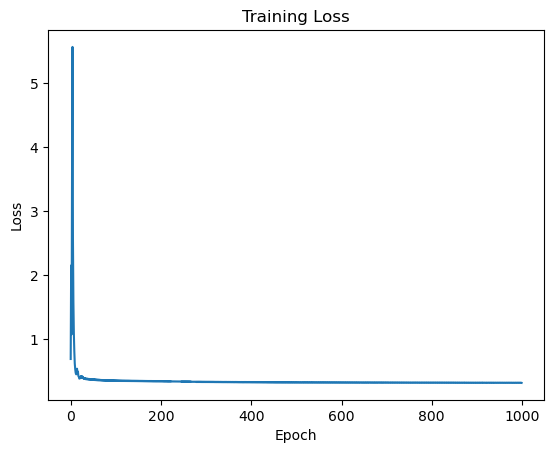

In [176]:
input_dim = X_train.shape[1]
hidden_dim = 50
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=10)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Epoch 100/1000, Loss: 0.3551
Epoch 200/1000, Loss: 0.3352
Epoch 300/1000, Loss: 0.3307
Epoch 400/1000, Loss: 0.3285
Epoch 500/1000, Loss: 0.3269
Epoch 600/1000, Loss: 0.3261
Epoch 700/1000, Loss: 0.3256
Epoch 800/1000, Loss: 0.3252
Epoch 900/1000, Loss: 0.3249
Epoch 1000/1000, Loss: 0.3246


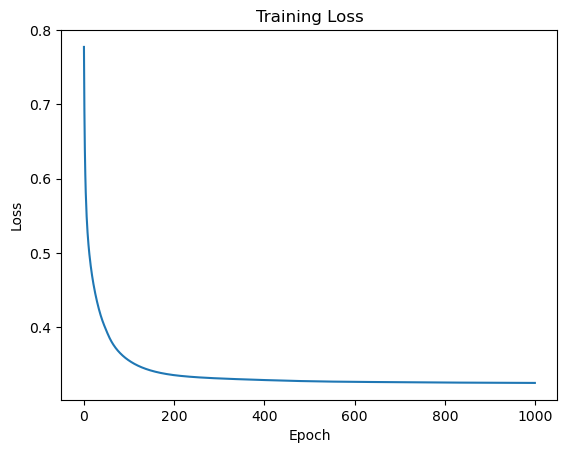

In [186]:
# For Single Hidden Layer
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
# criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.5)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Epoch 100/1000, Loss: 0.5517
Epoch 200/1000, Loss: 0.5515
Epoch 300/1000, Loss: 0.5512
Epoch 400/1000, Loss: 0.5507
Epoch 500/1000, Loss: 0.5496
Epoch 600/1000, Loss: 0.5464
Epoch 700/1000, Loss: 0.5311
Epoch 800/1000, Loss: 0.4507
Epoch 900/1000, Loss: 0.4072
Epoch 1000/1000, Loss: 0.3904


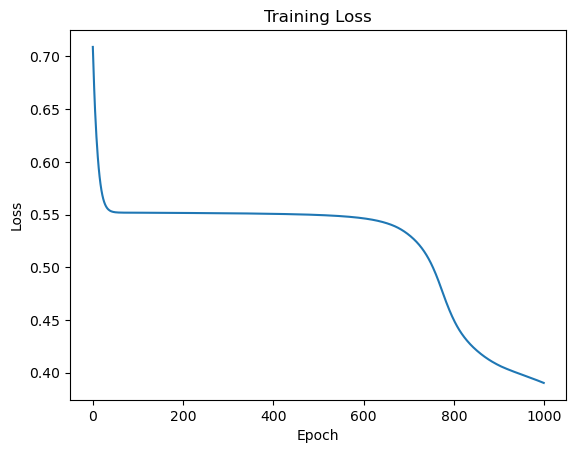

In [102]:
# For Multiple Hidden Layer
input_dim = X_train.shape[1]
hidden_dims = [10,10,10,10,10,10,10]
output_dim = 1

mlp = DeepMLP(input_dim, hidden_dims, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Epoch 100/1000, Total Loss: 0.4585
Epoch 200/1000, Total Loss: 0.4187
Epoch 300/1000, Total Loss: 0.4012
Epoch 400/1000, Total Loss: 0.3884
Epoch 500/1000, Total Loss: 0.3795
Epoch 600/1000, Total Loss: 0.3733
Epoch 700/1000, Total Loss: 0.3688
Epoch 800/1000, Total Loss: 0.3653
Epoch 900/1000, Total Loss: 0.3624
Epoch 1000/1000, Total Loss: 0.3599


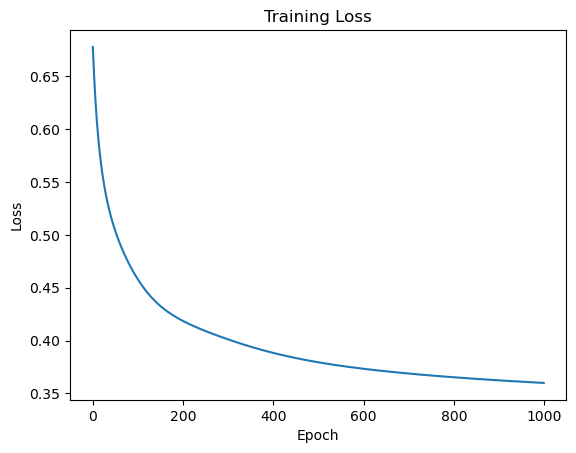

In [150]:
# For Different Loss Per Layer
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)

# Define loss functions
criterion_main = nn.BCELoss()  # Main loss (Binary Cross-Entropy)
criterion_aux = nn.MSELoss()   # Auxiliary loss for hidden layer

# Optimizer
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert Data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs, hidden_out = mlp(X_train_tensor)

    # Main Loss (Final Layer)
    main_loss = criterion_main(outputs, y_train_tensor)

    # Auxiliary Loss (Hidden Layer)
    aux_loss = criterion_aux(hidden_out, torch.zeros_like(hidden_out))  # Encourage small activations

    # Combined Loss
    total_loss = main_loss + 0.1 * aux_loss  # Weighted sum

    losses.append(total_loss.item())

    # Backward pass
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Total Loss: {total_loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# Step 5: Evaluate the MLP
- **Evaluation Function:**
  - Sets the model to evaluation mode using `model.eval()`.
  - Makes predictions by thresholding the output probabilities at 0.5 for binary classification.
  - Calculates accuracy by comparing predictions to actual labels.
- **Results:** Displays accuracy for both training and test datasets to assess model performance.

In [178]:
#base function
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8434
Test Accuracy: 0.8431


In [192]:
# For New Loss Function
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)  # Get raw logits
        probabilities = torch.sigmoid(logits)  # Convert to probabilities
        predictions = probabilities > 0.5  # Threshold at 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy
    
train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.2407
Test Accuracy: 0.2412


In [152]:
# For Different Loss Per Layer
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs, _ = model(X)  # Unpack (output, hidden_out)
        predictions = outputs > 0.5  # Convert logits to binary predictions
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

# Evaluate Model
train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.8377
Test Accuracy: 0.8440


In [159]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# For Other Evaluation Metrics 
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        # If you're using BCEWithLogitsLoss, apply sigmoid: outputs = torch.sigmoid(outputs)
        predictions = (outputs > 0.5).float()
    
    y_true = y.cpu().numpy()
    y_pred = predictions.cpu().numpy()
    
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred)
    }

# Evaluate the model
metrics = evaluate_model(mlp, X_test_tensor, y_test_tensor)
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")


Accuracy: 0.8492
Precision: 0.7485
Recall: 0.5646
F1 Score: 0.6437
